In [146]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import generic_filter

### GMIS

Brown de Colstoun, E. C., Huang, C., Wang, P., Tilton, J. C., Tan, B., Phillips, J., Niemczura, S., Ling, P.-Y., & Wolfe, R. E. (2017). Global Man-made Impervious Surface (GMIS) Dataset From Landsat (Version 1.00) [Data set]. Palisades, NY: NASA Socioeconomic Data and Applications Center (SEDAC). https://doi.org/10.7927/H4P55KKF Date Accessed: 2026-03-09

In [23]:
gmis_path = "gmis_extent.tif"

In [24]:
with rasterio.open(gmis_path) as src:
    arr = src.read(1).astype("float32")
    bounds = src.bounds 

In [25]:
arr[(arr == 200) | (arr == 255)] = np.nan

In [26]:
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

In [27]:
def fmt_lon(x, pos=None):
    return f"{x:.2f}°E"

def fmt_lat(y, pos=None):
    return f"{y:.2f}°N"

In [199]:
lon_step = 0.1
lat_step = 0.1

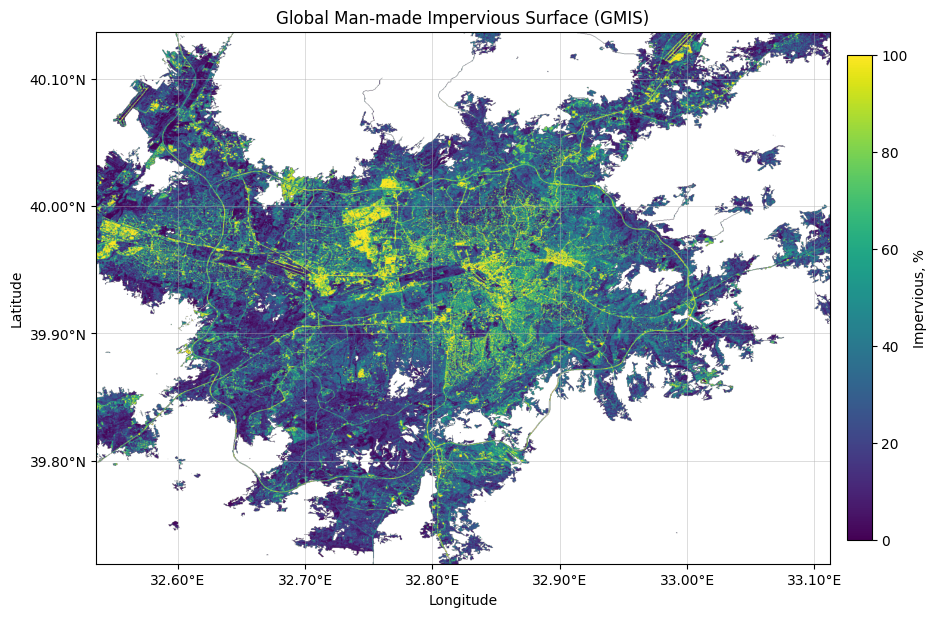

In [36]:
fig, ax = plt.subplots(figsize=(10, 10))

img = ax.imshow(
    arr,
    extent=extent,
    origin="upper",
    cmap="viridis",
    vmin=0,
    vmax=100)

ax.xaxis.set_major_locator(MultipleLocator(lon_step))
ax.yaxis.set_major_locator(MultipleLocator(lat_step))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
ax.grid(True, which="major", linewidth=0.6, alpha=0.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global Man-made Impervious Surface (GMIS)")

cbar = plt.colorbar(img, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Impervious, %")

plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### LCZ Generator

In [147]:
tif_path = "lcz.tif"

In [148]:
with rasterio.open(tif_path) as src:
    arr = src.read(1).astype("float32")
    bounds = src.bounds
    nodata = src.nodata

In [149]:
extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

In [180]:
def majority(values):
    vals = values[~np.isnan(values)]
    if len(vals) == 0:
        return np.nan
    vals = vals.astype(int)
    uniq, counts = np.unique(vals, return_counts=True)
    return uniq[np.argmax(counts)]

arr_smooth = generic_filter(arr, majority, size=3, mode="nearest")

In [181]:
colors = np.array([
    (140,   0,   0),   # 1 Compact High-Rise
    (209,   0,   0),   # 2 Compact Mid-Rise
    (255,   0,   0),   # 3 Compact Low-Rise
    (191,  77,   0),   # 4 Open High-Rise
    (255, 102,   0),   # 5 Open Mid-Rise
    (255, 153,  85),   # 6 Open Low-Rise
    (250, 238,   5),   # 7 Lightweight low-rise
    (188, 188, 188),   # 8 Large low-rise
    (255, 204, 170),   # 9 Sparsely built
    ( 85,  85,  85),   # 10 Heavy industry
    (  0, 106,   0),   # 11 Dense trees
    (  0, 170,   0),   # 12 Scattered trees
    (100, 133,  37),   # 13 Bush or scrub
    (185, 219, 121),   # 14 Low plants
    (  0,   0,   0),   # 15 Bare rock or paved
    (251, 247, 174),   # 16 Bare soil or sand
    (106, 106, 255),   # 17 Water
]) / 255.0

In [182]:
labels = [
    "1 Compact High-Rise",
    "2 Compact Mid-Rise",
    "3 Compact Low-Rise",
    "4 Open High-Rise",
    "5 Open Mid-Rise",
    "6 Open Low-Rise",
    "7 Lightweight low-rise",
    "8 Large low-rise",
    "9 Sparsely built",
    "10 Heavy industry",
    "11 Dense trees",
    "12 Scattered trees",
    "13 Bush or scrub",
    "14 Low plants",
    "15 Bare rock or paved",
    "16 Bare soil or sand",
    "17 Water"]

In [183]:
cmap = ListedColormap(colors)
cmap.set_bad("white")

In [184]:
bounds_classes = np.arange(0.5, 18, 1)
norm = BoundaryNorm(bounds_classes, cmap.N)

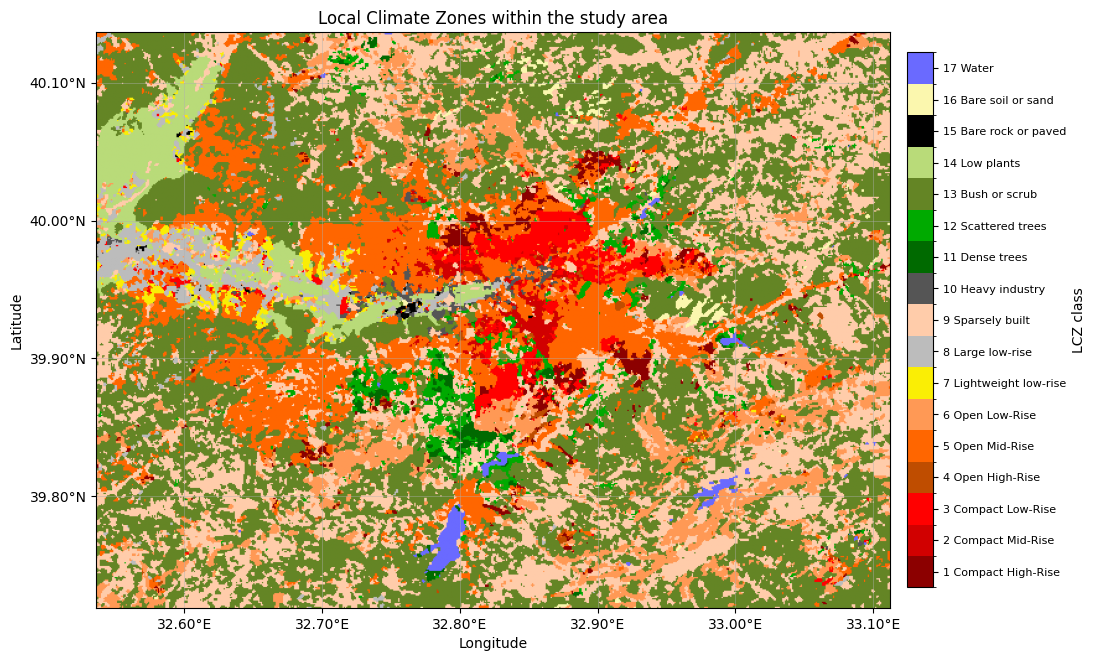

In [185]:
fig, ax = plt.subplots(figsize=(11, 11))

img = ax.imshow(
    arr_smooth,
    extent=extent,
    origin="upper",
    cmap=cmap,
    norm=norm)

ax.xaxis.set_major_locator(MultipleLocator(lon_step))
ax.yaxis.set_major_locator(MultipleLocator(lat_step))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
ax.grid(True, which="major", linewidth=0.6, alpha=0.5)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Local Climate Zones within the study area")

cbar = plt.colorbar(
    img,
    ax=ax,
    shrink=0.5,
    fraction=0.04,
    pad=0.02,
    ticks=np.arange(1, 18))

cbar.ax.set_yticklabels(labels)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("LCZ class", fontsize=10)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### CGLC

Buchhorn, M.; Smets, B.; Bertels, L.; Lesiv, M.; Tsendbazar, N.-E.; Masiliunas, D.; Linlin, L.; Herold,
M.; Fritz, S. (2020). Copernicus Global Land Service: Land Cover 100m: Collection 3: epoch
2019: Globe (Version V3.0.1) [Data set]. Zenodo. DOI: 10.5281/zenodo.3939049

In [189]:
cop = "copernicus.tif"

In [190]:
with rasterio.open(cop) as src:
    arr = src.read(1).astype("float32")
    bounds = src.bounds
    nodata = src.nodata

In [191]:
print(np.unique(arr))

[ 20.  30.  40.  50.  60.  80.  90. 111. 116. 121. 126.]


In [192]:
class_values = [
    20, 30, 40, 50, 60, 80, 90,
    111, 116, 121, 126]

In [196]:
class_info = {
    20: ("Shrubs", "#ffbb22"),
    30: ("Herbaceous vegetation", "#ffff4c"),
    40: ("Cropland", "#f096ff"),
    50: ("Urban / \nbuilt up", "#fa0000"),
    60: ("Bare / \nsparse vegetation", "#b4b4b4"),
    80: ("Permanent water bodies", "#0032c8"),
    90: ("Herbaceous wetland", "#0096a0"),
    111: ("Closed forest, \nevergreen needle leaf", "#58481f"),
    116: ("Closed forest, \nother", "#007800"),
    121: ("Open forest, \nevergreen needle leaf", "#666000"),
    126: ("Open forest, \nother", "#648c00"),}

In [197]:
mapped = np.full(arr.shape, np.nan, dtype=float)
for i, c in enumerate(class_values):
    mapped[arr == c] = i

mapped = np.ma.masked_invalid(mapped)

colors = [class_info[c][1] for c in class_values]
labels = [f"{c} {class_info[c][0]}" for c in class_values]

cmap = ListedColormap(colors)
norm = BoundaryNorm(np.arange(-0.5, len(class_values) + 0.5, 1), cmap.N)

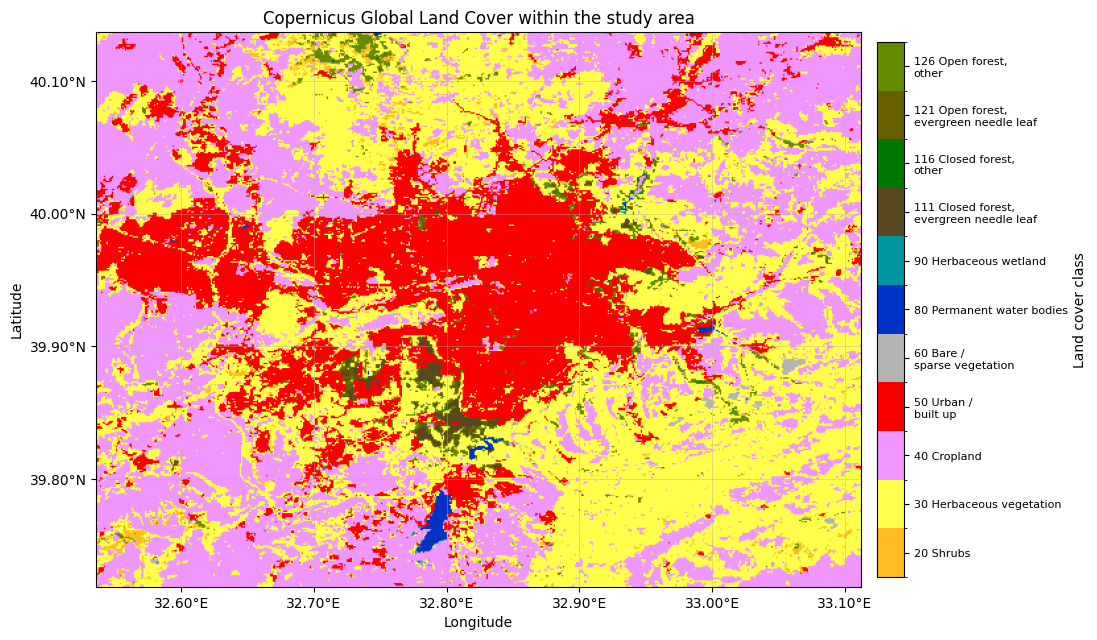

In [200]:
fig, ax = plt.subplots(figsize=(11, 11))

img = ax.imshow(
    mapped,
    extent=extent,
    origin="upper",
    cmap=cmap,
    norm=norm)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Copernicus Global Land Cover within the study area")

cbar = plt.colorbar(
    img,
    ax=ax,
    shrink=0.5,
    fraction=0.04,
    pad=0.02,
    ticks=np.arange(len(class_values)))

ax.xaxis.set_major_locator(MultipleLocator(lon_step))
ax.yaxis.set_major_locator(MultipleLocator(lat_step))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_lon))
ax.yaxis.set_major_formatter(FuncFormatter(fmt_lat))
ax.grid(True, which="major", linewidth=0.6, alpha=0.5)

cbar.ax.set_yticklabels(labels)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Land cover class", fontsize=10)

plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.setp(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()